In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca = PCA(n_components=2)

In [56]:
iris = load_iris()

In [57]:
X = iris.data
y = iris.target

(4.12, 8.08, 0.705, 7.195)

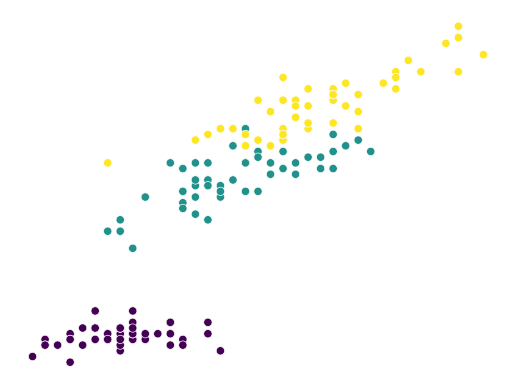

In [58]:
sns.scatterplot(x=X[:, 0], y=X[:, 2], c=y)
plt.axis(False)

In [59]:
X_scaled = scaler.fit_transform(X)

In [60]:
pca_data = pca.fit_transform(X_scaled)

In [61]:
wcss = []

for k in range(1, 21):

    k_means = KMeans(n_clusters=k)

    labels = k_means.fit_predict(X_scaled)

    wcss.append(k_means.inertia_)    

<Axes: >

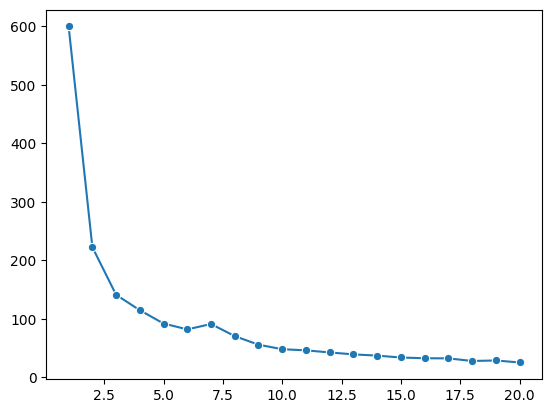

In [62]:
sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [66]:
k_means = KMeans(n_clusters=3)

labels = k_means.fit_predict(pca_data)

(-3.0785967172703907,
 3.6149475982769474,
 -2.9210906837189206,
 2.9533023502929496)

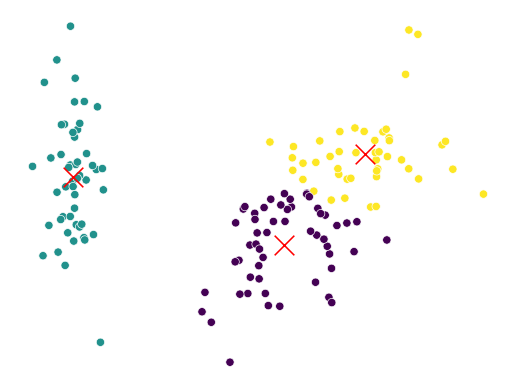

In [74]:
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c=labels)
sns.scatterplot(x=k_means.cluster_centers_[:, 0], y=k_means.cluster_centers_[:, 1], marker='x', c='r', s=200)
plt.axis(False)

In [2]:
df = load_iris(as_frame=True).frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df, 
    x='sepal length (cm)', 
    y='sepal width (cm)', 
    z='petal length (cm)', 
    color='petal width (cm)', # 4th feature gradient
    symbol='target',          # 
    title="Interactive 4D Iris Plot"
)
fig.show()